In [1]:
cd '/home/tomas/phoenix'

/home/tomas/phoenix


/home/tomas/miniconda3/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:

import math
import numpy as np
import pytest

from adaptHeisenberg.sigma0 import ProductState
from adaptHeisenberg.buffer_free_commutator_builder import build_commutator_buffered
from adaptHeisenberg.evolution import SystemBackend, FrozenBasisEvolver

from adaptHeisenberg.io_runlog import make_run_id, export_run


In [3]:
def _print_nonzeros(label: str, adaa, N: int, keymap, max_print: int = 50) -> int:
    print(label)

    shown = 0
    total = 0

    for i in range(adaa.size):
        v = adaa.data["real"][i]
        if abs(v) > 1e-12:
            total += 1

            if shown < max_print:
                nums, word = keymap.off2key(i).labels
                full = ["I"] * N
                for s, w in zip(nums, word):
                    full[int(s)] = str(w).upper()
                print(" ", "".join(full), float(v))
                shown += 1

    if total == 0:
        print("  (empty)")
    else:
        print(f"\n  → total nonzero terms: {total}")

    return total


In [6]:
def tail_weight_fraction(phi: np.ndarray, p: int) -> float:
    """ sum_{last p} |phi|^2 / sum_all |phi|^2 """
    if p <= 0:
        return 0.0
    denom = float(np.sum(np.abs(phi) ** 2))
    if denom == 0.0:
        return 0.0
    p = min(p, len(phi))
    numer = float(np.sum(np.abs(phi[-p:]) ** 2))
    return numer / denom


# -----------------
# params
# -----------------
N = 25
ell = 15
m_small = 3

p_tail = 2              # monitor last p coefficients
eps_tail = 1e-8         # trigger threshold on tail weight fraction

tmax = 3.
n_steps = 100
dt = tmax / n_steps
times = np.linspace(0.0, tmax, n_steps + 1)

# -----------------
# build commutator backend
# -----------------
commutate, SystemSmall, SystemBig, HamiltonADAA, km_small, km_big, km_ham = build_commutator_buffered(
    num_spins=N,
    m_small=m_small,
    h_body_max=2,
    real_only=True,
    recompile=False,
)

backend = SystemBackend(
    commutate=commutate,
    SystemSmall=SystemSmall,
    SystemBig=SystemBig,
    HamiltonADAA=HamiltonADAA,
    km_small=km_small,
    km_big=km_big,
    km_ham=km_ham,
)

# -----------------
# Hamiltonian: XY (+ optional tiny Jz for conditioning)
# -----------------
H = HamiltonADAA()
H.to_zero()
for j in range(N - 1):
    H.data["real"][km_ham.key2off((j, j + 1), "xx")] = 1.0
    H.data["real"][km_ham.key2off((j, j + 1), "yy")] = -1.0
    # optional: tiny Jz stabilizer
    H.data["real"][km_ham.key2off((j, j + 1), "zz")] = 1e-1

# -----------------
# sigma0 (example: all Z-polarized)
# -----------------
sigma0 = ProductState([.0, .0, .0] * N) ### referential

Id = SystemSmall()
Id.to_zero()
Id.data["real"][km_small.key2off((), "")] = 1.0

# -----------------
# initial seed operator b0 = Z0 (SMALL)
# -----------------
b0 = SystemSmall()
b0.to_zero()
b0.data["real"][km_small.key2off((0,), "z")] = 1

# -----------------
# build evolver (frozen basis)
# -----------------

Cannot use distutils backend with Python>=3.12, using meson backend instead.
Using meson backend
Will pass --lower to f2py
See https://numpy.org/doc/stable/f2py/buildtools/meson.html
Reading fortran codes...
	Reading file 'pauli_library_comm_buf.f90' (format:free)
Post-processing...
	Block: ecplib_comm_buf
			Block: pauli_library_comm_buf
				Block: commutate_000
				Block: commutate_001
				Block: commutate_002
				Block: commutate_003
				Block: commutate_004
				Block: commutate_005
				Block: commutate_006
				Block: commutate_007
				Block: commutate_008
				Block: commutate_009
				Block: commutate_010
				Block: commutate_011
				Block: commutate_012
				Block: commutate_013
				Block: commutate_014
				Block: commutate_015
				Block: commutate_016
				Block: commutate_017
				Block: commutate_018
				Block: commutate_019
				Block: commutate_020
				Block: commutate_021
				Block: commutate_022
				Block: commutate_023
				Block: commutate_024
				Block: commutate_025
				Block

The Meson build system
Version: 1.3.2
Source dir: /tmp/tmpwi9bi3xa
Build dir: /tmp/tmpwi9bi3xa/bbdir
Build type: native build
Project name: ecplib_comm_buf
Project version: 0.1
Fortran compiler for the host machine: gfortran (gcc 13.3.0 "GNU Fortran (Ubuntu 13.3.0-6ubuntu2~24.04) 13.3.0")
Fortran linker for the host machine: gfortran ld.bfd 2.42
C compiler for the host machine: cc (gcc 13.3.0 "cc (Ubuntu 13.3.0-6ubuntu2~24.04) 13.3.0")
C linker for the host machine: cc ld.bfd 2.42
Host machine cpu family: x86_64
Host machine cpu: x86_64
Program /home/tomas/miniconda3/bin/python found: YES (/home/tomas/miniconda3/bin/python)
Found pkg-config: YES (/usr/bin/pkg-config) 1.8.1
Run-time dependency python found: YES 3.12
Library quadmath found: YES
Build targets in project: 1

Found ninja-1.11.1 at /usr/bin/ninja
ninja: Entering directory `/tmp/tmpwi9bi3xa/bbdir'
[1/6] Module scanner.
[2/6] Compiling C object ecplib_comm_buf.cpython-312-x86_64-linux-gnu.so.p/6429abe6ab6341934029714386c8ccefb

In [8]:

### m = 3 HS 

evolver = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma0,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=1e-12,
).build(b0)



=== build() timing breakdown ===
scalar_product_setup  :   0.0000 s   (  0.00%)
build_basis           :   7.0569 s   ( 74.38%)
build_gram            :   1.2356 s   ( 13.02%)
build_Hij             :   1.1947 s   ( 12.59%)
prep_gram_pinv        :   0.0001 s   (  0.00%)
TOTAL                 :   9.4874 s   (100.00%)



In [5]:

### m = 3 

evolver = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma0,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=1e-12,
).build(b0)



=== build() timing breakdown ===
scalar_product_setup  :   0.0000 s   (  0.00%)
build_basis           :   8.7009 s   (  6.07%)
build_gram            :  91.1033 s   ( 63.52%)
build_Hij             :  43.6254 s   ( 30.42%)
prep_gram_pinv        :   0.0003 s   (  0.00%)
TOTAL                 : 143.4300 s   (100.00%)



In [5]:

### m = 3 

evolver = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma0,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=1e-12,
).build(b0)



=== build() timing breakdown ===
scalar_product_setup  :   0.0000 s   (  0.00%)
build_basis           :   7.4009 s   (  2.91%)
build_gram            :  83.1105 s   ( 32.70%)
build_Hij             : 163.6624 s   ( 64.39%)
prep_gram_pinv        :   0.0003 s   (  0.00%)
TOTAL                 : 254.1741 s   (100.00%)



In [6]:
term_count = [1.]
for k in range(ell):
    term_count.append(_print_nonzeros(f"b_{k+1}", adaa=evolver.basis[k], N=N, keymap=km_small))

b_1
  ZIIIIIIIIIIIIIIIIIIIIIIII 1.0

  → total nonzero terms: 1
b_2
  XYIIIIIIIIIIIIIIIIIIIIIII -2.0
  YXIIIIIIIIIIIIIIIIIIIIIII -2.0

  → total nonzero terms: 2
b_3
  ZIIIIIIIIIIIIIIIIIIIIIIII -8.0
  IZIIIIIIIIIIIIIIIIIIIIIII -8.0
  XXZIIIIIIIIIIIIIIIIIIIIII 0.4
  XZXIIIIIIIIIIIIIIIIIIIIII -4.0
  YYZIIIIIIIIIIIIIIIIIIIIII -0.4
  YZYIIIIIIIIIIIIIIIIIIIIII -4.0

  → total nonzero terms: 6
b_4
  XYIIIIIIIIIIIIIIIIIIIIIII 40.08
  YXIIIIIIIIIIIIIIIIIIIIIII 40.08
  XIYIIIIIIIIIIIIIIIIIIIIII -0.09312000000000009
  YIXIIIIIIIIIIIIIIIIIIIIII 0.09312000000000009
  XIIYIIIIIIIIIIIIIIIIIIIII 7.0687999999999995
  YIIXIIIIIIIIIIIIIIIIIIIII 7.0687999999999995
  IXYIIIIIIIIIIIIIIIIIIIIII 24.0
  IYXIIIIIIIIIIIIIIIIIIIIII 24.0
  XZYIIIIIIIIIIIIIIIIIIIIII -0.752
  YZXIIIIIIIIIIIIIIIIIIIIII 0.752
  XZIYIIIIIIIIIIIIIIIIIIIII -7.52
  YZIXIIIIIIIIIIIIIIIIIIIII -7.52
  XIYZIIIIIIIIIIIIIIIIIIIII -0.752
  XIZYIIIIIIIIIIIIIIIIIIIII -7.52
  YIXZIIIIIIIIIIIIIIIIIIIII 0.752
  YIZXIIIIIIIIIIIIIIIIIIIII -7.52

  → t

In [9]:

### m = 2 

evolver = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma0,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=1e-12,
).build(b0)



=== build() timing breakdown ===
scalar_product_setup  :   0.0000 s   (  0.00%)
build_basis           :   0.1947 s   (  1.34%)
build_gram            :   4.5539 s   ( 31.25%)
build_Hij             :   9.8256 s   ( 67.42%)
prep_gram_pinv        :   0.0001 s   (  0.00%)
TOTAL                 :  14.5743 s   (100.00%)



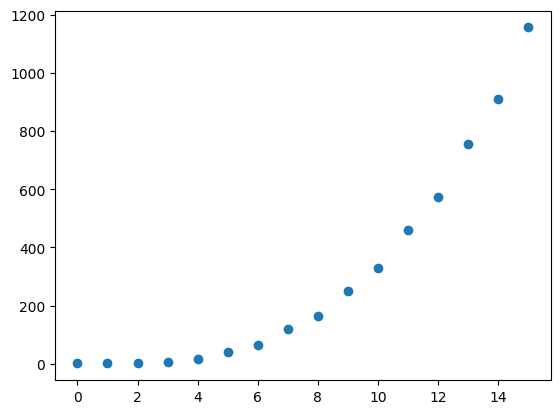

In [7]:
import matplotlib.pyplot as plt
plt.scatter([_ for _ in range(ell+1)], term_count)

In [9]:
x = [i for i in range(ell+1)]

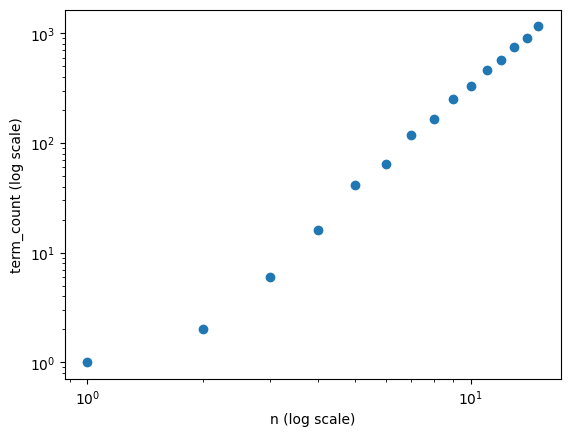

In [10]:
plt.scatter(x, term_count)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (log scale)")
plt.ylabel("term_count (log scale)")
plt.show()


In [5]:
start = time()

evolver = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma0,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=1e-12,
).build(b0)

time() - start


=== build() timing breakdown ===
scalar_product_setup  :   0.0000 s   (  0.02%)
build_basis           :   0.0262 s   ( 60.97%)
build_gram            :   0.0064 s   ( 14.82%)
build_Hij             :   0.0103 s   ( 23.98%)
prep_gram_pinv        :   0.0001 s   (  0.19%)
TOTAL                 :   0.0429 s   (100.00%)



0.04329729080200195

In [5]:
start = time()

evolver = FrozenBasisEvolver(
    backend=backend,
    ham=H,
    sigma0=sigma0,
    m_small=m_small,
    ell=ell,
    exclude_scalar=False,
    pinv_rtol=1e-12,
).build(b0)

time() - start

0.058028459548950195